In [1]:
!pip install pulp

In [2]:
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

acc = pd.read_csv("accidents.csv")
veh = pd.read_csv("vehicles.csv")

print("Accidents columns:", acc.columns)
print("Vehicles columns:", veh.columns)

acc.head(), veh.head()

Accidents columns: Index(['States/UTs',
       'State/UT-Wise Total Number of Road Accidents during-2009',
       'State/UT-Wise Total Number of Road Accidents during-2010',
       'State/UT-Wise Total Number of Road Accidents during-2011',
       'State/UT-Wise Total Number of Road Accidents during-2012',
       'Share of States/UTs in Total Number of Road Accidents-2009',
       'Share of States/UTs in Total Number of Road Accidents-2010',
       'Share of States/UTs in Total Number of Road Accidents-2011',
       'Share of States/UTs in Total Number of Road Accidents-2012',
       'Total Number of Accidents Per Lakh Population-2009',
       'Total Number of Accidents Per Lakh Population-2010',
       'Total Number of Accidents Per Lakh Population-2011',
       'Total Number of Accidents Per Lakh Population-2012',
       'Total Number of Road Accidents per 10000 Vehicles-2009',
       'Total Number of Road Accidents per 10000 Vehicles-2010',
       'Total Number of Road Accidents per

(          States/UTs  \
 0     Andhra Pradesh   
 1  Arunachal Pradesh   
 2              Assam   
 3              Bihar   
 4       Chhattisgarh   
 
    State/UT-Wise Total Number of Road Accidents during-2009  \
 0                                              43600          
 1                                                306          
 2                                               4869          
 3                                              10065          
 4                                              12888          
 
    State/UT-Wise Total Number of Road Accidents during-2010  \
 0                                              44599          
 1                                                293          
 2                                               5828          
 3                                              11033          
 4                                              13664          
 
    State/UT-Wise Total Number of Road Accidents during-2011  \
 0          

In [4]:
df = acc.copy()

# Rename columns for simplicity (2011 is best - stable year)
df = df[['States/UTs',
         'State/UT-Wise Total Number of Road Accidents during-2011',
         'Total Number of Accidents Per Lakh Population-2011',
         'Total Number of Road Accidents per 10000 Vehicles-2011']]

df.columns = ['state', 'accidents', 'acc_per_lakh_pop', 'acc_per_10k_veh']

# Remove total row if exists
df = df[~df['state'].str.contains("Total", case=False)]

df = df.dropna()

df.head()

,state,accidents,acc_per_lakh_pop,acc_per_10k_veh
0,Andhra Pradesh,44165,52.16,43.34
1,Arunachal Pradesh,263,19.02,18.20
2,Assam,6569,21.08,41.52
3,Bihar,10673,10.28,39.93
4,Chhattisgarh,14108,55.24,51.00


In [6]:
# Convert to numeric
df['accidents'] = pd.to_numeric(df['accidents'], errors='coerce')
df['acc_per_lakh_pop'] = pd.to_numeric(df['acc_per_lakh_pop'], errors='coerce')
df['acc_per_10k_veh'] = pd.to_numeric(df['acc_per_10k_veh'], errors='coerce')

df = df.dropna()

In [7]:
df['safety_output'] = 1 / df['accidents']

In [8]:
df.head()
df.shape

(35, 5)

Now we have clean data,we build the actual optimization model.

In [9]:
def dea_input_oriented(df, inputs, outputs):
    efficiency_scores = []

    for i in range(len(df)):
        prob = pulp.LpProblem("DEA", pulp.LpMinimize)

        # Efficiency variable
        theta = pulp.LpVariable("theta", lowBound=0)

        # Lambda variables
        lambdas = pulp.LpVariable.dicts("lambda", range(len(df)), lowBound=0)

        # Objective
        prob += theta

        # Input constraints
        for inp in inputs:
            prob += pulp.lpSum([lambdas[j] * df.iloc[j][inp] for j in range(len(df))]) <= theta * df.iloc[i][inp]

        # Output constraints
        for out in outputs:
            prob += pulp.lpSum([lambdas[j] * df.iloc[j][out] for j in range(len(df))]) >= df.iloc[i][out]

        # Solve
        prob.solve(pulp.PULP_CBC_CMD(msg=0))

        efficiency_scores.append(pulp.value(theta))

    return efficiency_scores

Now, let's define the input and output variables.

In [10]:
inputs = ['acc_per_lakh_pop', 'acc_per_10k_veh']
outputs = ['safety_output']

Let's clean our dataset even more for NA or inf values before we proceed with the DEA optimization.

In [13]:
df.isnull().sum()

,0
state,0
accidents,0
acc_per_lakh_pop,0
acc_per_10k_veh,0
safety_output,0


In [14]:
df.describe()

,accidents,acc_per_lakh_pop,acc_per_10k_veh,safety_output
count,35.000000,35.000000,35.000000,35.000000
mean,14219.600000,47.598857,33.080857,inf
std,19468.579557,54.191811,22.495589,NaN
min,0.000000,0.000000,0.000000,0.000015
25%,518.000000,19.615000,16.315000,0.000055
50%,6513.000000,33.870000,33.510000,0.000154
75%,19095.000000,58.070000,44.740000,0.001979
max,68438.000000,312.820000,104.690000,inf


In [15]:
df[df['accidents'] == 0]

,state,accidents,acc_per_lakh_pop,acc_per_10k_veh,safety_output
33,Lakshadweep,0,0.0,0.0,inf


Let's clean our data for these null values and inf values.

In [16]:
df = df[df['accidents'] > 0]

In [17]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [18]:
df['safety_output'] = 1 / df['accidents']

Let's proceed with the DEA optimization now.

In [19]:
df['efficiency_score'] = dea_input_oriented(df, inputs, outputs)

In [20]:
df.describe()

,accidents,acc_per_lakh_pop,acc_per_10k_veh,safety_output,efficiency_score
count,34.000000,34.000000,34.000000,34.000000,34.000000
mean,14637.823529,48.998824,34.053824,0.002533,0.040677
std,19601.117828,54.360551,22.073721,0.005751,0.172727
min,39.000000,1.970000,1.430000,0.000015,0.000020
25%,622.250000,20.302500,17.682500,0.000049,0.000119
50%,6541.000000,37.650000,33.685000,0.000153,0.000624
75%,21170.000000,59.485000,44.890000,0.001613,0.004289
max,68438.000000,312.820000,104.690000,0.025641,1.000000


The distribution of efficiency scores is highly skewed, with only a few states operating on the efficiency frontier while the majority exhibit significant inefficiencies.”

Let's get some more insights.

Top states from our study.

In [21]:
df_sorted = df.sort_values(by='efficiency_score', ascending=False)

df_sorted[['state', 'efficiency_score']].head(10)

,state,efficiency_score
18,Nagaland,1.000000
31,Daman and Diu,0.173199
17,Mizoram,0.089096
30,Dadra and Nagar Haveli,0.040138
29,Chandigarh,0.029406
1,Arunachal Pradesh,0.015359
28,Andaman and Nicobar Islands,0.007039
16,Meghalaya,0.006347
15,Manipur,0.004368
24,Tripura,0.004055


Now, let's look at the worst performing states in India.


In [22]:
df_sorted[['state', 'efficiency_score']].tail(10)

,state,efficiency_score
26,Uttar Pradesh,0.000179
4,Chhattisgarh,0.000099
21,Rajasthan,0.000098
6,Gujarat,0.000079
0,Andhra Pradesh,0.000033
11,Karnataka,0.000028
12,Kerala,0.000027
13,Madhya Pradesh,0.000023
14,Maharashtra,0.000021
23,Tamil Nadu,0.000020


Now, let's check the most efficient states in India from our data.

In [23]:
df[df['efficiency_score'] >= 0.999]

,state,accidents,acc_per_lakh_pop,acc_per_10k_veh,safety_output,efficiency_score
18,Nagaland,39,1.97,1.43,0.025641,1.0


Now let's find some more info.


In [24]:
df_sorted[['state', 'accidents', 'acc_per_10k_veh', 'efficiency_score']].head(10)

,state,accidents,acc_per_10k_veh,efficiency_score
18,Nagaland,39,1.43,1.000000
31,Daman and Diu,50,6.44,0.173199
17,Mizoram,97,10.47,0.089096
30,Dadra and Nagar Haveli,103,13.49,0.040138
29,Chandigarh,437,4.34,0.029406
1,Arunachal Pradesh,263,18.20,0.015359
28,Andaman and Nicobar Islands,234,33.86,0.007039
16,Meghalaya,599,34.09,0.006347
15,Manipur,692,33.51,0.004368
24,Tripura,834,44.44,0.004055


Let's visualize the DEA Efficiency vs Traffic Risk Exposure

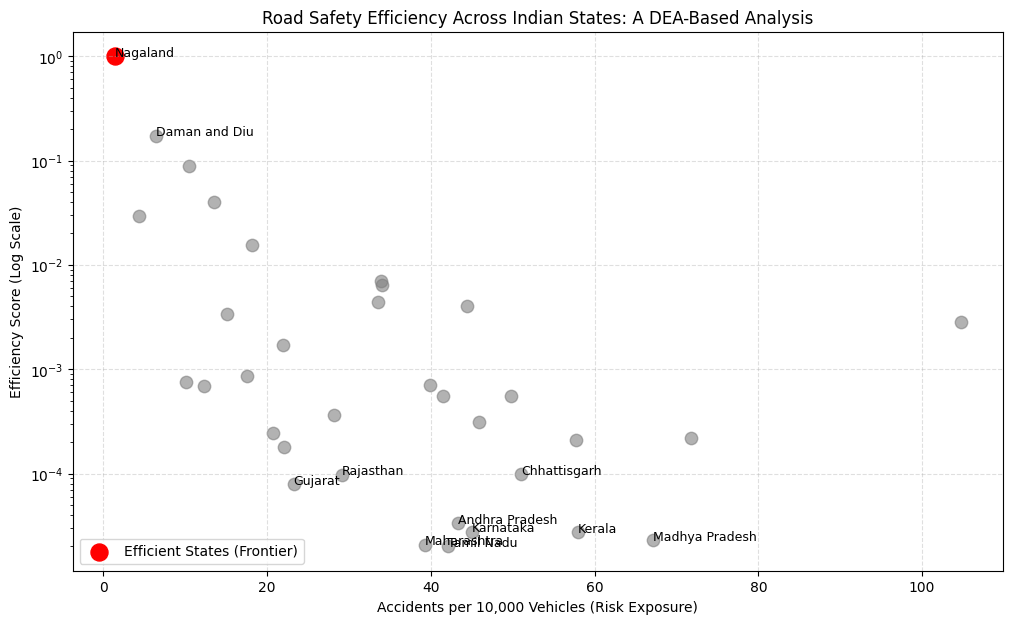

In [29]:
plt.figure(figsize=(12,7))

# Base points
plt.scatter(
    df['acc_per_10k_veh'],
    df['efficiency_score'],
    color='grey',
    s=80,
    alpha=0.6
)

# Highlight efficient states
efficient = df[df['efficiency_score'] >= 0.9]
plt.scatter(
    efficient['acc_per_10k_veh'],
    efficient['efficiency_score'],
    color='red',
    s=150,
    label='Efficient States (Frontier)'
)

# Log scale
plt.yscale('log')

# Labels (key only)
for i in range(len(df)):
    y = df['efficiency_score'].iloc[i]
    if y > 0.1 or y < 0.0001:
        plt.text(df['acc_per_10k_veh'].iloc[i],
                 y,
                 df['state'].iloc[i],
                 fontsize=9)

plt.xlabel("Accidents per 10,000 Vehicles (Risk Exposure)")
plt.ylabel("Efficiency Score (Log Scale)")
plt.title("Road Safety Efficiency Across Indian States: A DEA-Based Analysis")

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='lower left')

plt.show()